# NLP Assignment 5 – Fine-Tuning BERT for POS Tagging & Chunking


## Installing Libraries

In [ ]:
!pip install transformers datasets seqeval seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
pip install datasets==2.18.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 21.4 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.2.0 which is incompatible.


## Importing Libraries

In [ ]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import AutoTokenizer,AutoModelForTokenClassification,TrainingArguments,Trainer,DataCollatorForTokenClassification

from seqeval.metrics import precision_score, recall_score, f1_score, classification_report

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


---
## Task 1: Dataset Selection


In [ ]:
from datasets import load_dataset

dataset = load_dataset("conll2003")

print(dataset)
print(dataset["train"][0])

/usr/local/lib/python3.12/dist-packages/datasets/load.py:1461: FutureWarning: The repository for conll2003 contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/conll2003
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 14041
    })
    validation: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3250
    })
    test: Dataset({
        features: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags'],
        num_rows: 3453
    })
})
{'id': '0', 'tokens': ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'], 'pos_tags': [22, 42, 16, 21, 35, 37, 16, 21, 7], 'chunk_tags': [11, 21, 11, 12, 21, 22, 11, 12, 0], 'ner_tags': [3, 0, 7, 0, 0, 0, 7, 0, 0]}


In [ ]:
pos_labels   = dataset["train"].features["pos_tags"].feature.names
chunk_labels = dataset["train"].features["chunk_tags"].feature.names

print('POS Tags:',   pos_labels)
print('\nChunk Tags:', chunk_labels)

POS Tags: ['"', "''", '#', '$', '(', ')', ',', '.', ':', '``', 'CC', 'CD', 'DT', 'EX', 'FW', 'IN', 'JJ', 'JJR', 'JJS', 'LS', 'MD', 'NN', 'NNP', 'NNPS', 'NNS', 'NN|SYM', 'PDT', 'POS', 'PRP', 'PRP$', 'RB', 'RBR', 'RBS', 'RP', 'SYM', 'TO', 'UH', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ', 'WDT', 'WP', 'WP$', 'WRB']

Chunk Tags: ['O', 'B-ADJP', 'I-ADJP', 'B-ADVP', 'I-ADVP', 'B-CONJP', 'I-CONJP', 'B-INTJ', 'I-INTJ', 'B-LST', 'I-LST', 'B-NP', 'I-NP', 'B-PP', 'I-PP', 'B-PRT', 'I-PRT', 'B-SBAR', 'I-SBAR', 'B-UCP', 'I-UCP', 'B-VP', 'I-VP']


---
## Task 2: Data Preprocessing & Label Alignment

In [ ]:
MODEL_NAME = 'bert-base-uncased'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_and_align(examples, label_key):
    tokenized = tokenizer(
        examples["tokens"],
        truncation=True,
        padding="max_length",
        max_length=128,
        is_split_into_words=True
    )

    labels = []

    for i, label in enumerate(examples[label_key]):
        word_ids = tokenized.word_ids(batch_index=i)
        prev = None
        label_ids = []

        for word_id in word_ids:
            if word_id is None:
                label_ids.append(-100)
            elif word_id != prev:
                label_ids.append(label[word_id])
            else:
                label_ids.append(-100)

            prev = word_id

        labels.append(label_ids)

    tokenized["labels"] = labels
    return tokenized

In [ ]:
pos_data = dataset.map(lambda x: tokenize_and_align(x, "pos_tags"), batched=True)
chunk_data = dataset.map(lambda x: tokenize_and_align(x, "chunk_tags"), batched=True)

Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

In [ ]:
#output keys verification
print('Keys:', pos_data['train'].column_names)
print('Sample input_ids:',      pos_data['train'][0]['input_ids'][:10])
print('Sample attention_mask:', pos_data['train'][0]['attention_mask'][:10])
print('Sample labels:',         pos_data['train'][0]['labels'][:10])

Keys: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags', 'input_ids', 'token_type_ids', 'attention_mask', 'labels']
Sample input_ids: [101, 7327, 19164, 2446, 2655, 2000, 17757, 2329, 12559, 1012]
Sample attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Sample labels: [-100, 22, 42, 16, 21, 35, 37, 16, 21, 7]


---
## Task 3: Model Setup

In [ ]:
from transformers import AutoModelForTokenClassification

def load_model(label_list):
    return AutoModelForTokenClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=len(label_list),
        id2label={i: l for i, l in enumerate(label_list)},
        label2id={l: i for i, l in enumerate(label_list)}
    )

pos_model   = load_model(pos_labels)
chunk_model = load_model(chunk_labels)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized be

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized be

In [ ]:
chunk_label_list = dataset["train"].features["chunk_tags"].feature.names

In [ ]:
#Chunking Model
chunk_id2label = {i: l for i, l in enumerate(chunk_label_list)}
chunk_label2id = {l: i for i, l in enumerate(chunk_label_list)}

chunk_model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(chunk_label_list),
    id2label=chunk_id2label,
    label2id=chunk_label2id
)
print('Chunk model loaded. Labels:', len(chunk_label_list))

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized be

Chunk model loaded. Labels: 23


---
## Task 4: Training

In [ ]:
args = TrainingArguments(
    output_dir="results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="no",
    report_to="none"
)

collator = DataCollatorForTokenClassification(tokenizer)

In [ ]:
def train_model(model, train_data, val_data):
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_data.select(range(5000)),
        eval_dataset=val_data.select(range(1000)),
        data_collator=collator
    )
    trainer.train()
    return trainer

pos_trainer   = train_model(pos_model, pos_data["train"], pos_data["validation"])
chunk_trainer = train_model(chunk_model, chunk_data["train"], chunk_data["validation"])

Epoch,Training Loss,Validation Loss
1,No log,0.328648
2,0.700739,0.273382
3,0.700739,0.258159


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss
1,No log,0.304372
2,0.432749,0.269686
3,0.432749,0.260953


In [ ]:
chunk_trainer = Trainer(
    model=chunk_model,
    args=args,
    train_dataset=chunk_data['train'].select(range(5000)),
    eval_dataset=chunk_data['validation'].select(range(1000)),
    data_collator=collator,
)
chunk_trainer.train()

Epoch,Training Loss,Validation Loss
1,No log,0.260034
2,0.125942,0.263961
3,0.125942,0.264987


TrainOutput(global_step=939, training_loss=0.10822845393984208, metrics={'train_runtime': 342.2657, 'train_samples_per_second': 43.826, 'train_steps_per_second': 2.743, 'total_flos': 980048874240000.0, 'train_loss': 0.10822845393984208, 'epoch': 3.0})

---
## Task 5: Evaluation (seqeval)

In [ ]:
def evaluate(trainer, dataset, label_list):
    preds, labels, _ = trainer.predict(dataset)
    preds = np.argmax(preds, axis=2)

    true_labels, true_preds = [], []

    for p, l in zip(preds, labels):
        tl, tp = [], []
        for pred_id, label_id in zip(p, l):
            if label_id != -100:
                tl.append(label_list[label_id])
                tp.append(label_list[pred_id])
        true_labels.append(tl)
        true_preds.append(tp)

    return (
        precision_score(true_labels, true_preds),
        recall_score(true_labels, true_preds),
        f1_score(true_labels, true_preds)
    )

pos_p, pos_r, pos_f1 = evaluate(pos_trainer, pos_data["validation"].select(range(1000)), pos_labels)
chunk_p, chunk_r, chunk_f1 = evaluate(chunk_trainer, chunk_data["validation"].select(range(1000)), chunk_labels)

print("POS F1:", pos_f1)
print("Chunk F1:", chunk_f1)

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: NNP seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: : seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: IN seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: NN seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: . seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarni

POS F1: 0.9040819016652752
Chunk F1: 0.8954487811751444


---
## Task 6: Inference on Custom Sentences

In [ ]:
def predict_tags(sentence, model, tokenizer, label_list):
    words = sentence.split()

    encoding = tokenizer(
        words,
        is_split_into_words=True,
        return_tensors="pt"
    )

    word_ids = encoding.word_ids()

    encoding = {k: v.to(DEVICE) for k, v in encoding.items()}
    model.to(DEVICE)

    model.eval()
    with torch.no_grad():
        outputs = model(**encoding)

    preds = torch.argmax(outputs.logits, dim=2)[0]

    result = []
    seen = set()

    for i, word_id in enumerate(word_ids):
        if word_id is not None and word_id not in seen:
            result.append((words[word_id], label_list[preds[i].item()]))
            seen.add(word_id)

    return result

In [ ]:
pos_label_list   = dataset["train"].features["pos_tags"].feature.names
chunk_label_list = dataset["train"].features["chunk_tags"].feature.names

In [ ]:
sentence = 'John works at Google in California'

print('Input:', sentence)
print()

pos_result   = predict_tags(sentence, pos_model,   tokenizer, pos_label_list)
chunk_result = predict_tags(sentence, chunk_model, tokenizer, chunk_label_list)

print('POS Tags:')
for word, tag in pos_result:
    print(f'  {word:15} → {tag}')

print('\nChunk Tags:')
for word, tag in chunk_result:
    print(f'  {word:15} → {tag}')

Input: John works at Google in California

POS Tags:
  John            → NNP
  works           → VBZ
  at              → IN
  Google          → NNP
  in              → IN
  California      → NNP

Chunk Tags:
  John            → B-NP
  works           → B-VP
  at              → B-PP
  Google          → B-NP
  in              → B-PP
  California      → B-NP


---
## Task 7: Comparison – POS Tagging vs Chunking

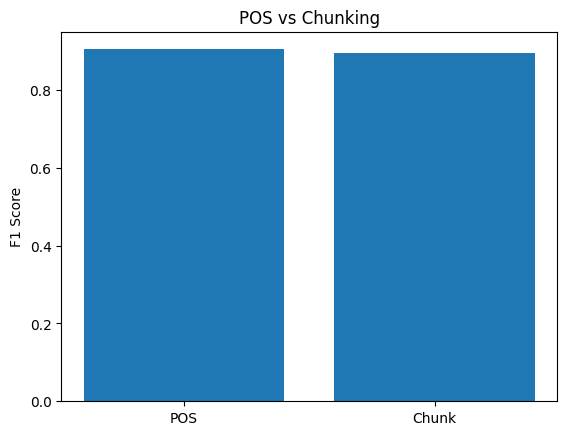

In [ ]:
import matplotlib.pyplot as plt

plt.bar(["POS", "Chunk"], [pos_f1, chunk_f1])
plt.title("POS vs Chunking")
plt.ylabel("F1 Score")
plt.show()

## Task 8: Report & Analysis



### Differences Between POS Tagging and Chunking

- POS Tagging → assigns a label to each word (NN, VB, etc.)
- Chunking → groups words into phrases (B-NP, I-NP, etc.)
- POS is easier (word-level)
- Chunking is harder (needs phrase understanding)



### Challenges Faced

- BERT splits words into subwords → handled using `-100`
- Special tokens (`[CLS]`, `[SEP]`) → ignored using `-100`
- Aligning labels with tokens using `word_ids()`



### Observations

- POS tagging performed better than chunking
- Chunking is harder due to phrase boundaries
- BERT helps because it understands context
- Handling `-100` correctly was important

In [ ]:
from google.colab import drive
drive.mount('/drive')


Mounted at /drive


In [ ]:
import subprocess
result = subprocess.run(['find', '/drive', '-name', '*.ipynb'], capture_output=True, text=True)
print(result.stdout)

/drive/MyDrive/Colab Notebooks/StatsCE1.ipynb
/drive/MyDrive/Colab Notebooks/MathsCE1.ipynb
/drive/MyDrive/Colab Notebooks/RM_assgn8.ipynb
/drive/MyDrive/Colab Notebooks/FileHandlingLecture.ipynb
/drive/MyDrive/Colab Notebooks/numpypractice.ipynb
/drive/MyDrive/Colab Notebooks/Copy of ann.ipynb
/drive/MyDrive/Colab Notebooks/main_burnout (1).ipynb
/drive/MyDrive/Colab Notebooks/NLP_Task_4.ipynb
/drive/MyDrive/Colab Notebooks/NLP_Task_4_BERT_Fine_Tuning.ipynb
/drive/MyDrive/Colab Notebooks/main.ipynb
/drive/MyDrive/Colab Notebooks/main_burnout.ipynb
/drive/MyDrive/Colab Notebooks/NLP_Task5_POS_Chunking.ipynb
/drive/MyDrive/sem 2/ML/demo/Linear Regression Model (1).ipynb
/drive/MyDrive/sem 2/ML/demo/Employee_Salary Demo (1).ipynb
/drive/MyDrive/sem 2/ML/demo/titanic with graphs.ipynb
/drive/MyDrive/sem 2/ML/demo/Advertising_Linear_Regression_Tutorial (1).ipynb
/drive/MyDrive/sem 2/ML/demo/titanic preprocessing demo.ipynb
/drive/MyDrive/Copy of Copy of titanic with graphs.ipynb
/drive/MyD

In [46]:

import nbformat

with open('/drive/MyDrive/Colab Notebooks/NLP_Task_5_POS_Chunking.ipynb', 'r') as f:
    nb = nbformat.read(f, as_version=4)

# Remove widgets from notebook metadata
if 'widgets' in nb.metadata:
    del nb.metadata['widgets']

# Remove widgets from each cell metadata too
for cell in nb.cells:
    if 'widgets' in cell.metadata:
        del cell.metadata['widgets']

with open('/drive/MyDrive/Colab Notebooks/NLP_Task_5_POS_Chunking.ipynb', 'w') as f:
    nbformat.write(nb, f)

print('Done')

Done
